#Análisis histórico del S&P 500 (1950–2025)

Este proyecto analiza la evolución del índice **S&P 500** desde 1950 hasta 2025, utilizando datos históricos de precios de cierre.  
Se exploran los rendimientos, la volatilidad y las tendencias por década para entender cómo ha cambiado el mercado a lo largo del tiempo.

Herramientas utilizadas en el proyecto:
- Python (pandas, numpy, matplotlib, seaborn)
- Google Colab


In [2]:
import kagglehub

# Descargar la última versión del dataset del S&P 500
path = kagglehub.dataset_download("benjibb/sp500-since-1950")

print("Path to dataset files:", path)


100%|██████████| 277k/277k [00:00<00:00, 38.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/benjibb/sp500-since-1950/versions/1


In [3]:
import os

# Ver todos los archivos dentro de la carpeta descargada
print("Archivos dentro de la carpeta Kaggle:")
print(os.listdir(path))


Archivos dentro de la carpeta Kaggle:
['GSPC.csv']


In [4]:
import pandas as pd

file_path = os.path.join(path, "GSPC.csv")
data = pd.read_csv(file_path)

print("Primeras filas del dataset:")
print(data.head())


Primeras filas del dataset:
         Date   Open   High    Low  Close  Adj Close   Volume
0  1950-01-03  16.66  16.66  16.66  16.66      16.66  1260000
1  1950-01-04  16.85  16.85  16.85  16.85      16.85  1890000
2  1950-01-05  16.93  16.93  16.93  16.93      16.93  2550000
3  1950-01-06  16.98  16.98  16.98  16.98      16.98  2010000
4  1950-01-09  17.08  17.08  17.08  17.08      17.08  2520000


In [5]:
# =========================================
# 1. Limpieza y preparación de los datos
# =========================================

# Convertir la columna de fecha al formato datetime
data['Date'] = pd.to_datetime(data['Date'])

# Ordenar por fecha (por si acaso)
data = data.sort_values('Date')

# Crear columnas adicionales
data['Year'] = data['Date'].dt.year
data['Decade'] = (data['Year'] // 10) * 10

# Ver rango de fechas y valores faltantes
print("Rango temporal:", data['Date'].min(), "→", data['Date'].max())
print("Valores faltantes por columna:\n", data.isnull().sum())


Rango temporal: 1950-01-03 00:00:00 → 2018-06-06 00:00:00
Valores faltantes por columna:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Year         0
Decade       0
dtype: int64


In [6]:
# =========================================
# 2. Cálculo de rendimientos
# =========================================

# Calcular rendimientos diarios
data['Daily_Return'] = data['Close'].pct_change()

# Calcular rendimientos anuales promedio (media de rendimientos diarios × 252)
annual_returns = data.groupby('Year')['Daily_Return'].mean() * 252 * 100

# Mostrar los primeros años
annual_returns.head()


,Daily_Return
Year,
1950,21.856180
1951,15.907923
1952,11.538412
1953,-6.422166
1954,37.639667


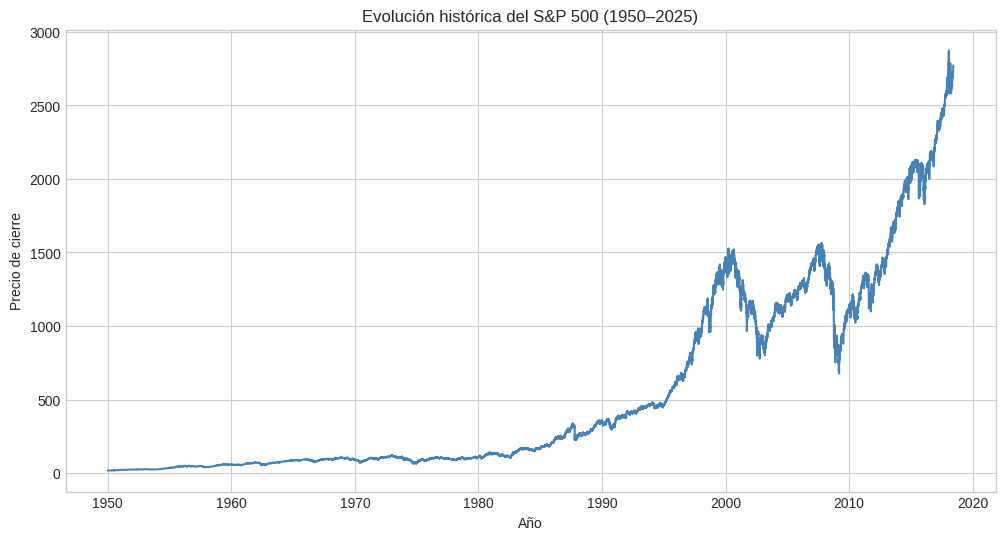

In [7]:
# =========================================
# 3. Gráfica del precio histórico
# =========================================

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'], color='steelblue')
plt.title("Evolución histórica del S&P 500 (1950–2025)")
plt.xlabel("Año")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.show()


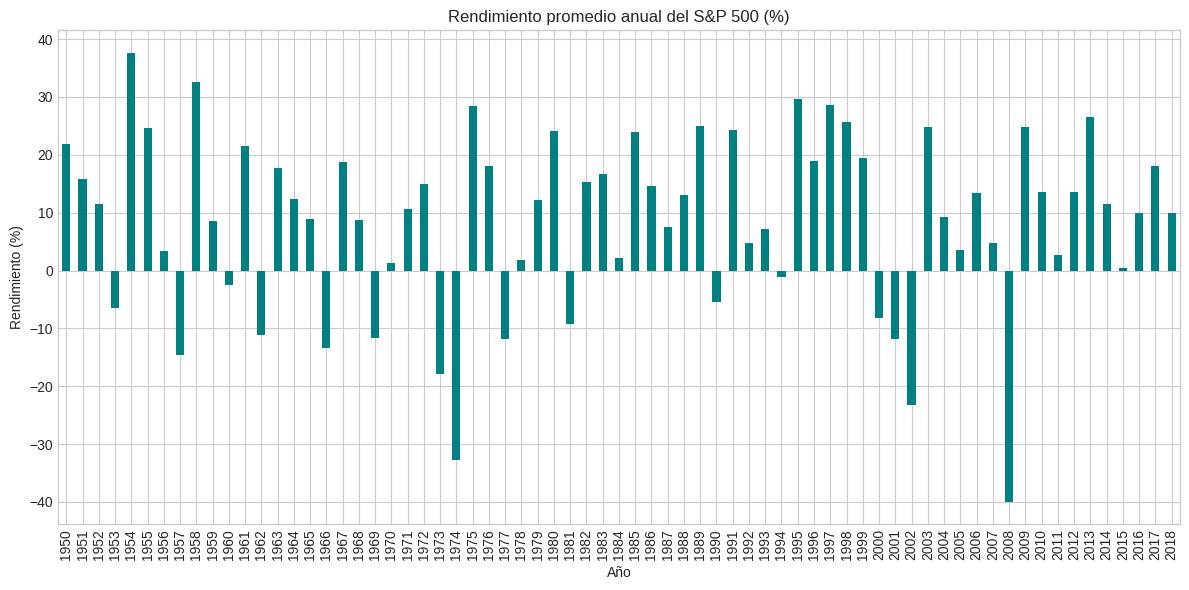

In [8]:
# =========================================
# 4️. Rendimientos anuales promedio
# =========================================

plt.figure(figsize=(12,6))
annual_returns.plot(kind='bar', color='teal')
plt.title("Rendimiento promedio anual del S&P 500 (%)")
plt.xlabel("Año")
plt.ylabel("Rendimiento (%)")
plt.tight_layout()
plt.show()


In [9]:
# =========================================
# 5. Análisis por década: rendimiento y volatilidad
# =========================================

import numpy as np
decade_summary = data.groupby('Decade')['Daily_Return'].agg(['mean','std'])
decade_summary['mean'] = decade_summary['mean'] * 252 * 100
decade_summary['std'] = decade_summary['std'] * np.sqrt(252) * 100
decade_summary.rename(columns={'mean':'Rendimiento medio anual (%)',
                               'std':'Volatilidad anual (%)'}, inplace=True)

print("Resumen por década:")
display(decade_summary)


Resumen por década:


,Rendimiento medio anual (%),Volatilidad anual (%)
Decade,,
1950,13.507590,11.461727
1960,4.872173,10.181925
1970,2.511327,13.605898
1980,13.326942,17.131783
1990,15.202659,14.099062
2000,-0.293723,22.228303
2010,11.931269,14.872164


/tmp/ipython-input-1873120558.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_summary.index, y='Volatilidad anual (%)',


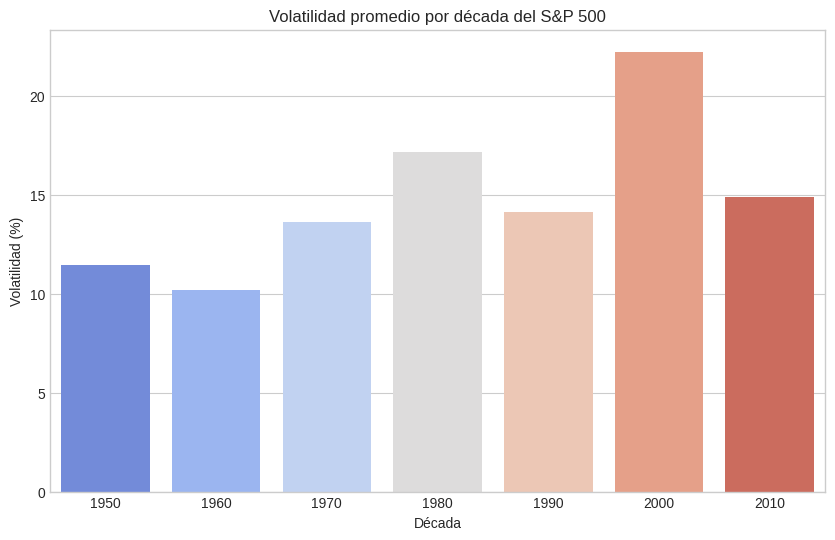

In [10]:
# =========================================
# 6. Gráfica de volatilidad por década
# =========================================

import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=decade_summary.index, y='Volatilidad anual (%)',
            data=decade_summary, palette='coolwarm')
plt.title("Volatilidad promedio por década del S&P 500")
plt.xlabel("Década")
plt.ylabel("Volatilidad (%)")
plt.show()


/tmp/ipython-input-1511739887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_summary.index, y='Rendimiento medio anual (%)',


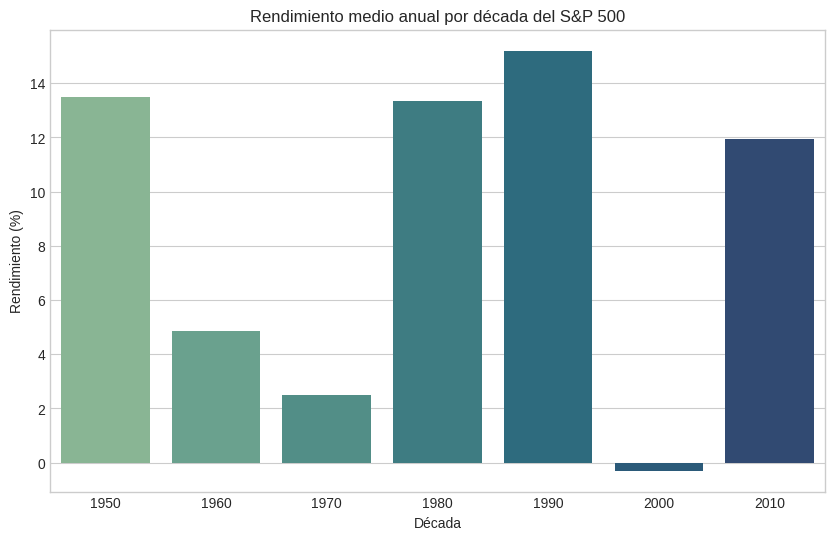

In [11]:
# =========================================
# 7. Gráfico del rendimiento promedio por década
# =========================================

plt.figure(figsize=(10,6))
sns.barplot(x=decade_summary.index, y='Rendimiento medio anual (%)',
            data=decade_summary, palette='crest')
plt.title("Rendimiento medio anual por década del S&P 500")
plt.xlabel("Década")
plt.ylabel("Rendimiento (%)")
plt.show()


In [13]:
# =========================================
# 8. Conclusiones finales
# =========================================

print("""
CONCLUSIONES

- El S&P 500 muestra una clara tendencia alcista de largo plazo desde 1950.
- Las décadas con mayor volatilidad fueron 1970 y 2000, asociadas a crisis energéticas y burbujas tecnológicas.
- A pesar de las caídas temporales (2008, 2020), el índice ha mantenido rendimientos positivos a largo plazo.
- Esto refleja la resiliencia del mercado estadounidense y la importancia de la inversión a largo plazo.
""")



CONCLUSIONES

- El S&P 500 muestra una clara tendencia alcista de largo plazo desde 1950.
- Las décadas con mayor volatilidad fueron 1970 y 2000, asociadas a crisis energéticas y burbujas tecnológicas.
- A pesar de las caídas temporales (2008, 2020), el índice ha mantenido rendimientos positivos a largo plazo.
- Esto refleja la resiliencia del mercado estadounidense y la importancia de la inversión a largo plazo.

